# 07 - U-Net (segmentação de defeitos) — Tarefa 3

A U-Net é treinada de forma **supervisionada** com as máscaras de *ground truth*
do MVTec, para **localizar ao pixel** a zona do defeito.

> Lê os artefactos de `scripts/train_unet_category.py` e
> `scripts/eval_unet_category.py`.

## 0. Setup

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
RESULTS = ROOT / "results"
MODELS = ROOT / "models"
sys.path.append(str(SRC))
sys.path.append(str(ROOT / "scripts"))  # dataset da U-Net

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])


def carregar_json(c):
    with open(c, encoding="utf-8") as f:
        return json.load(f)


def existe(c):
    c = Path(c)
    if not c.exists():
        print(f"[FALTA] {c.name} — corre o script correspondente primeiro.")
        return False
    return True


def desnormalizar(t):
    img = t.detach().cpu().numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)


def mostrar_matriz_confusao(matriz, etiquetas, titulo, ax=None):
    matriz = np.asarray(matriz)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(matriz, cmap="Blues")
    ax.set_title(titulo)
    ax.set_xticks(range(len(etiquetas))); ax.set_yticks(range(len(etiquetas)))
    ax.set_xticklabels(etiquetas, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(etiquetas, fontsize=8)
    ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
    lim = matriz.max() / 2 if matriz.max() else 0.5
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(j, i, int(matriz[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if matriz[i, j] > lim else "black")
    return ax

print("ROOT:", ROOT, "| device:", device)

ROOT: C:\Users\maria\Desktop\projeto | device: cuda


## 1. Métricas de segmentação por categoria (Pixel-AUROC, IoU, Dice)

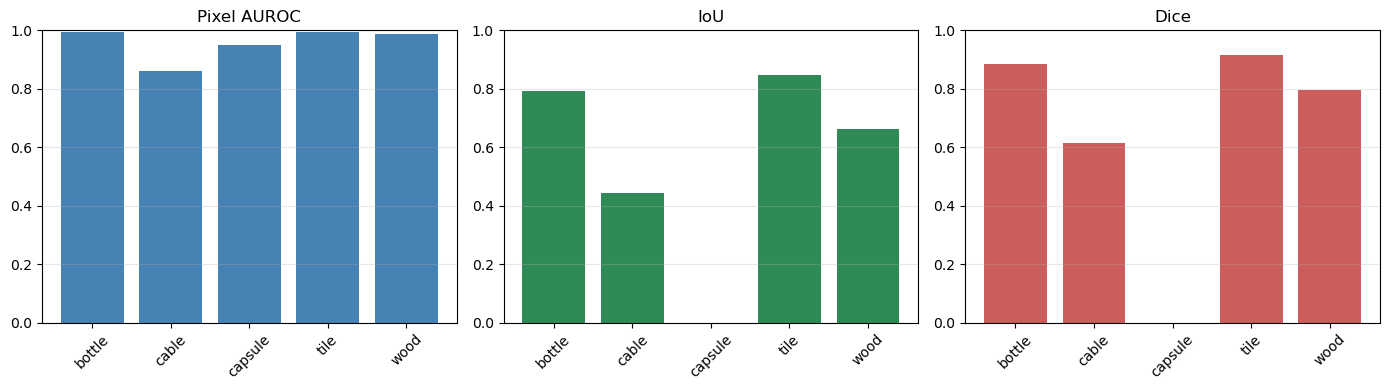

,category,pixel_auroc,iou,dice
0,bottle,0.9930,0.7928,0.8844
1,cable,0.8596,0.4450,0.6159
2,capsule,0.9484,0.0000,0.0000
3,tile,0.9929,0.8461,0.9167
4,wood,0.9880,0.6624,0.7969


In [2]:
import pandas as pd
caminho = RESULTS / "unet_summary.csv"
if existe(caminho):
    df = pd.read_csv(caminho)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].bar(df["category"], df["pixel_auroc"], color="steelblue"); axes[0].set_title("Pixel AUROC")
    axes[1].bar(df["category"], df["iou"], color="seagreen"); axes[1].set_title("IoU")
    axes[2].bar(df["category"], df["dice"], color="indianred"); axes[2].set_title("Dice")
    for ax in axes:
        ax.set_ylim(0, 1); ax.tick_params(axis="x", rotation=45); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()
    display(df.round(4))

## 2. Overlays de segmentação (com Dice por imagem)

Para cada exemplo: **imagem · máscara real · máscara prevista · overlay**. O
título mostra o **Dice** dessa imagem (verde se Dice > 0.5, vermelho caso contrário).

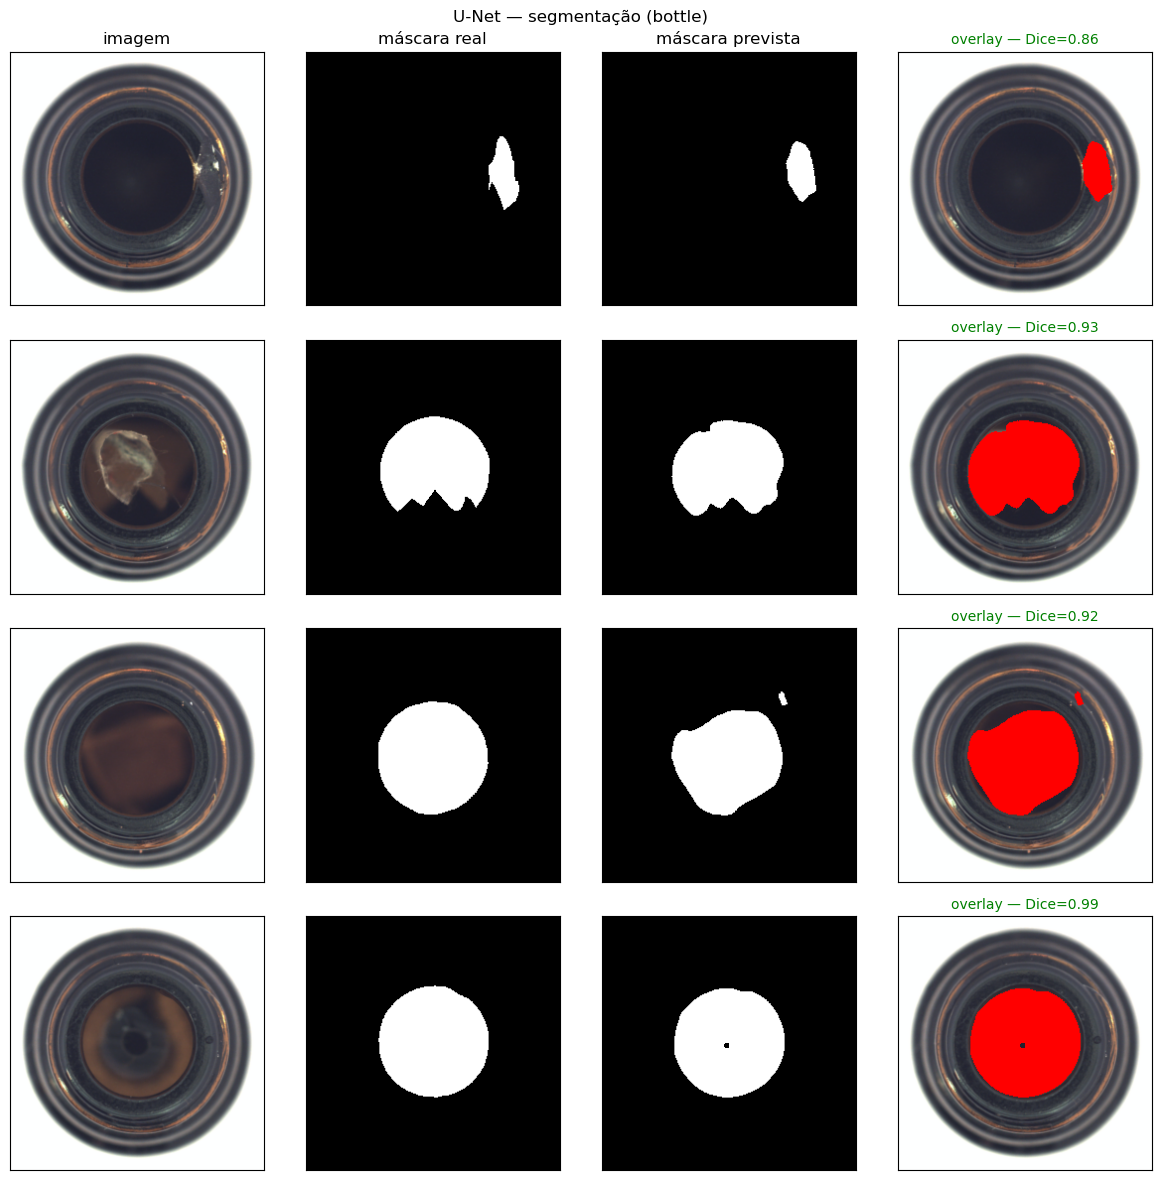

In [3]:
from unet import UNet
CATEGORIA = "bottle"
caminho_modelo = MODELS / f"unet_{CATEGORIA}_best.pth"
caminho_split = MODELS / f"unet_{CATEGORIA}_test_split.pt"
if existe(caminho_modelo) and existe(caminho_split):
    modelo = UNet().to(device)
    modelo.load_state_dict(torch.load(caminho_modelo, map_location=device)); modelo.eval()
    test_ds = torch.load(caminho_split, weights_only=False)
    n = min(4, len(test_ds))
    fig, axes = plt.subplots(n, 4, figsize=(12, 3 * n)); axes = np.atleast_2d(axes)
    for i in range(n):
        image, mask = test_ds[i]
        with torch.no_grad():
            pred = torch.sigmoid(modelo(image.unsqueeze(0).to(device))).squeeze().cpu().numpy()
        pred_bin = (pred > 0.5).astype(np.uint8); mask_np = mask.squeeze().numpy().astype(np.uint8)
        inter = int((pred_bin & mask_np).sum()); soma = int(pred_bin.sum() + mask_np.sum())
        dice = (2 * inter / soma) if soma else 0.0
        cor = "green" if dice > 0.5 else "red"
        img_np = desnormalizar(image); overlay = img_np.copy(); overlay[pred_bin == 1] = [1, 0, 0]
        axes[i, 0].imshow(img_np); axes[i, 0].set_title("imagem" if i == 0 else "")
        axes[i, 1].imshow(mask_np, cmap="gray"); axes[i, 1].set_title("máscara real" if i == 0 else "")
        axes[i, 2].imshow(pred_bin, cmap="gray"); axes[i, 2].set_title("máscara prevista" if i == 0 else "")
        axes[i, 3].imshow(overlay); axes[i, 3].set_title(f"overlay — Dice={dice:.2f}", color=cor, fontsize=10)
        for c in range(4):
            axes[i, c].set_xticks([]); axes[i, c].set_yticks([])
    plt.suptitle(f"U-Net — segmentação ({CATEGORIA})"); plt.tight_layout(); plt.show()

## 3. Localização: U-Net vs Autoencoder (bottle)

A U-Net (supervisionada, com máscaras) localiza muito melhor que o autoencoder
(não supervisionado). Comparação direta de IoU e Dice ao pixel:

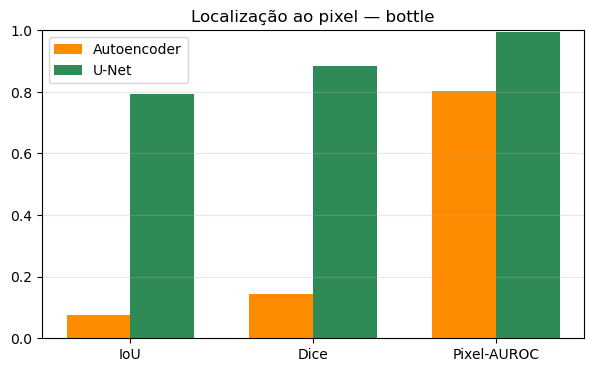

IoU   — autoencoder: 0.077  |  U-Net: 0.793
Dice  — autoencoder: 0.142  |  U-Net: 0.884


In [4]:
cam_unet = RESULTS / "unet_bottle_metrics.json"
cam_ae = RESULTS / "autoencoder_bottle_metrics.json"
if existe(cam_unet) and existe(cam_ae):
    unet_m = carregar_json(cam_unet)["metrics"]; ae_m = carregar_json(cam_ae)["pixel_metrics"]
    unet_vals = [unet_m["iou"], unet_m["dice"], unet_m["pixel_auroc"]]
    ae_vals = [ae_m["iou"], ae_m["dice"], ae_m["pixel_auroc"]]
    x = np.arange(3); w = 0.35
    plt.figure(figsize=(7, 4))
    plt.bar(x - w / 2, ae_vals, w, label="Autoencoder", color="darkorange")
    plt.bar(x + w / 2, unet_vals, w, label="U-Net", color="seagreen")
    plt.xticks(x, ["IoU", "Dice", "Pixel-AUROC"]); plt.ylim(0, 1)
    plt.title("Localização ao pixel — bottle"); plt.legend(); plt.grid(axis="y", alpha=0.3); plt.show()
    print(f"IoU   — autoencoder: {ae_vals[0]:.3f}  |  U-Net: {unet_vals[0]:.3f}")
    print(f"Dice  — autoencoder: {ae_vals[1]:.3f}  |  U-Net: {unet_vals[1]:.3f}")